## 🦙 라마인덱스(LlamaIndex)를 공부해 보자!

### **라마인덱스(LlamaIndex)란**

- 라마인덱스(LlamaIndex)는 최신 AI 모델(LLM)에 외부 데이터(회사 문서, 데이터베이스, PDF 등)를 연결하여 맞춤형 AI 서비스를 만들 수 있도록 도와주는 오픈소스 프레임워크입니다.
- ChatGPT 같은 AI에게 "우리 회사 규정집"이나 "내 개인 메모장"을 학습시켜서 전문적으로 답변하게 만들어주는 데이터 다리(Data Bridge) 역할을 합니다.

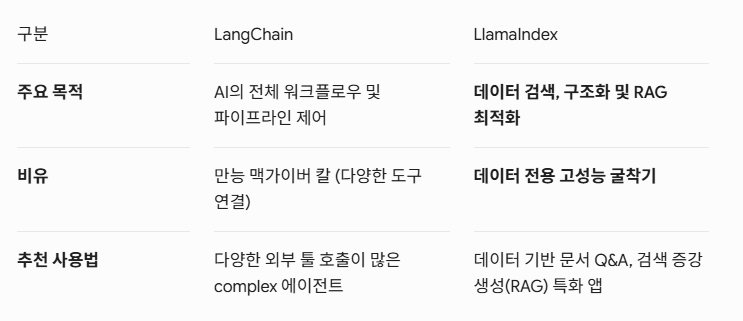

#### 라마인덱스(LlamaIndex)가 제공하는 주요 기능 
- 데이터 수집 및 연결 (Data Ingestion / Connectors)
- 데이터 분할 및 구조화 (Indexing & Structuring)
- 검색 및 답변 합성 (Retrieval & Query Engine)
- 자율형 데이터 에이전트 (Data Agents)

In [ ]:
!pip install llama-index llama-index-llms-ollama llama-index-embeddings-ollama

In [ ]:
import llama_index.core

print("LlamaIndex Core Version:", llama_index.core.__version__)

In [ ]:
from llama_index.llms.ollama import Ollama

llm = Ollama(model="exaone3.5", request_timeout=180.0)
response = llm.complete("대한민국의 수도는 어디야?")
print(response)

In [ ]:
print(type(llm))
print(llm)

In [ ]:
from llama_index.core.llms import ChatMessage, MessageRole
from llama_index.llms.ollama import Ollama

llm = Ollama(model="exaone3.5", request_timeout=180.0)

messages = [
    ChatMessage(role=MessageRole.SYSTEM, content="너는 친절한 개발자 멘토야."),
    ChatMessage(role=MessageRole.USER, content="파이썬의 타입 힌트 구문에 대해 정리해줘"),
]

response = llm.chat(messages)
print(response)

In [ ]:
print(type(response))
print(dir(response))

In [ ]:
response.model_dump_json()

In [ ]:
import json
json_str = response.model_dump_json()
data = json.loads(json_str)
usage = data.get("raw", {}).get("usage")
print(usage)

In [ ]:
print(response.message)

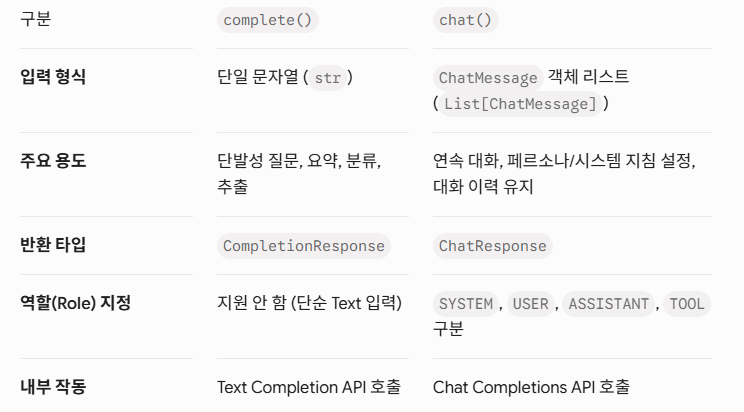

In [ ]:
from llama_index.llms.ollama import Ollama

llm = Ollama(model="exaone3.5", request_timeout=360.0)
response = llm.complete("김정현 강사의 별명은 뭐야?")
print(response)

In [ ]:
response = llm.complete("김정현 강사는 어디에서 살고 있나요?")
print(response)

#### **인메모리 벡터 저장소 사용한 RAG 구현**

- VectorStoreIndex.from_documents()를 사용해서 인메모리 벡터 저장소를 기본값으로 사용합니다.
- 호출하는 순간 문서를 청크(Chunk)로 나누고 임베딩을 생성하여 메모리에 올려둔 뒤 바로 검색할 수 있게 합니다.
- 즉석 테스트, POC(개념검증), 사용자 세션별 임시 문서 처리, 일회성 문서 처리에 사용합니다.


#### Ollama 임베딩 모델 설치 : ollama pull bge-m3

In [ ]:
import os
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, Settings
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.ollama import OllamaEmbedding

In [ ]:
# ---------------------------------------------------------
# 1. Ollama LLM 및 임베딩 모델 설정
# ---------------------------------------------------------
# Ollama LLM 연결 (기본 URL: http://localhost:11434)
llm = Ollama(
    model="exaone3.5",
    request_timeout=360.0,
    temperature=0.1  # 환각 현상을 줄이기 위해 낮은 값 설정
)

# Ollama 로컬 임베딩 모델 연결
embed_model = OllamaEmbedding(
    model_name="bge-m3",
    base_url="http://localhost:11434"
)

# LlamaIndex 전역 설정(Settings)에 적용
# 생성한 LLM 객체를 LlamaIndex의 전역 기본 LLM으로 등록하여, Query Engine이나 Agent 등을 만들 때 
# 매번 llm=llm을 전달하지 않아도 되게 하는 설정
Settings.llm = llm
Settings.embed_model = embed_model

In [ ]:
print(type(Settings.llm))
print(Settings.llm)
print()
print(type(Settings.embed_model))
print(Settings.embed_model)

In [ ]:
# ---------------------------------------------------------
# 2. 문서 로드 및 인덱싱 (Indexing)
# ---------------------------------------------------------
DATA_DIR = "./llamadata"

# data 디렉터리가 없으면 생성하고 샘플 파일 작성
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
with open(f"{DATA_DIR}/sample.txt", "w", encoding="utf-8") as f:
    f.write("김정현 강사의 별명은 유니코입니다.\n")
    f.write("김정현 강사는 수원에서 살고 있습니다.")

In [ ]:
documents = SimpleDirectoryReader(
    input_files=["./llamadata/sample.txt"]
).load_data()

print("⚡ 벡터 인덱스 생성 중 (로컬 임베딩 수행)...")
index = VectorStoreIndex.from_documents(documents)
print("⚡ 벡터 인덱스 생성 완료 (로컬 임베딩 완료)...")

In [ ]:
print(documents)
print(index)

In [ ]:
# ---------------------------------------------------------
# 3. 질의응답 (Querying)
# ---------------------------------------------------------
# 검색 및 응답 생성을 담당하는 Query Engine 생성
query_engine = index.as_query_engine(
    similarity_top_k=3  # 검색할 관련 문서 수
)

In [ ]:
print(type(query_engine))

- RetrieverQueryEngine은 검색(Retriever) ➔ 후처리(Postprocessor) ➔ 응답 생성(Synthesizer) 흐름을 연결하는 LlamaIndex의 핵심 엔진 클래스입니다.
- 단순히 index.as_query_engine()을 쓰는 수준을 넘어 하이브리드 검색, Reranker 적용, 거절 지침 프롬프트 세팅 등 고급 RAG 파이프라인을 커스텀할 때 직접 호출해서 사용합니다.

In [ ]:
query = "김정현 강사의 별명은 무엇인가요?"
print(f"\n❓ 질문: {query}\n")
# 질의 실행
response = query_engine.query(query)
# 결과 출력
print("🤖 답변:",response)

In [ ]:
print(query_engine.query("김정현 강사의 어디에서 살고 있나요?"))

### Open AI 의 gpt 모델도 사용해 보자

In [ ]:
from llama_index.llms.openai import OpenAI

# OpenAI API는 응답이 빠르므로 timeout을 60초 내외로 설정하셔도 충분
llm = OpenAI(model="gpt-4o-mini", request_timeout=60.0)

response = llm.complete("대한민국의 수도는 어디야?")
print(response)

In [ ]:
print(type(llm))
print(llm)

In [ ]:
from llama_index.core.llms import ChatMessage, MessageRole
messages = [
    ChatMessage(role=MessageRole.SYSTEM, content="너는 친절한 개발자 멘토야."),
    ChatMessage(role=MessageRole.USER, content="파이썬의 타입힌트 구문에 대해 정리해줘"),
]

response = llm.chat(messages)
print(response)

In [ ]:
messages = [
    ChatMessage(role=MessageRole.SYSTEM, content="너는 김정현 강사의 절친이야."),
    ChatMessage(role=MessageRole.USER, content="김정현 강사가 사는 곳을 알려줘"),
]

response = llm.chat(messages)
print(response)

#### 인메모리 벡터 인덱스로 첫 RAG 만들기

`VectorStoreIndex`는 LlamaIndex의 가장 기본적인 인덱스입니다.
별도 설정이 없으면 **메모리 안에** 벡터를 저장합니다. (프로세스가 끝나면 사라짐)

내부 동작:
1. `Settings.node_parser`(기본값 `SentenceSplitter`)로 Document를 Node로 분할
2. `Settings.embed_model`로 각 Node를 임베딩
3. 벡터를 인메모리 저장소(`SimpleVectorStore`)에 저장

In [ ]:
from llama_index.core import Settings
from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding

llm = OpenAI(
    model="gpt-4o-mini",
    temperature=0.1,  # 환각 현상을 줄이기 위해 낮은 값 설정
    request_timeout=60.0  # OpenAI API는 응답이 빠르므로 60초면 충분합니다.
)

# 3. OpenAI 임베딩 모델 설정
embed_model = OpenAIEmbedding(
    model="text-embedding-3-small"
)

# 4. LlamaIndex 전역 설정(Settings)에 적용
Settings.llm = llm
Settings.embed_model = embed_model

### 💡 SimpleDirectoryReader가 지원하는 파일 형식
`.txt`, `.pdf`, `.docx`, `.csv`, `.md`, `.pptx`, `.html`, 이미지 파일 등
매우 다양한 형식을 자동으로 감지해서 읽어줍니다. (내부적으로 파일 확장자별 Reader를 자동 선택)

In [ ]:
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex

documents = SimpleDirectoryReader(
    input_files=["./llamadata/sample.txt"]
).load_data()

print("⚡ 벡터 인덱스 생성 중 (로컬 임베딩 수행)...")
index = VectorStoreIndex.from_documents(documents)
print("⚡ 벡터 인덱스 생성 완료 (로컬 임베딩 완료)...")

In [ ]:
print(documents)

In [ ]:
query_engine = index.as_query_engine(
    similarity_top_k=3  # 검색할 관련 문서 수
)

In [ ]:
print(query_engine.query("김정현 강사의 어디에서 살고 있나요?"))

In [ ]:
print(query_engine.query("김정현 강사의 별명은 무엇인가요?"))

In [ ]:
print(query_engine.query("대한민국의 수도는 어디인가요?"))

In [ ]:
from llama_index.core import PromptTemplate

# 문맥(Context)에 없을 때의 행동 지침을 명확히 정의
text_qa_template_str = (
    "아래에 제공된 참고 문서 정보만을 바탕으로 질문에 답변하세요.\n"
    "만약 제공된 문서 정보 내에서 질문에 대한 답을 찾을 수 없다면, "
    "절대로 추측하거나 지어내지 말고 '제공된 문서에서 관련 정보를 찾을 수 없습니다.'라고만 답변하세요.\n\n"
    "---------------------\n"
    "참고 문서:\n{context_str}\n"
    "---------------------\n"
    "질문: {query_str}\n"
    "답변: "
)

text_qa_template = PromptTemplate(text_qa_template_str)

# query_engine 생성 시 프롬프트 적용
query_engine = index.as_query_engine(
    similarity_top_k=3,
    text_qa_template=text_qa_template
)

In [ ]:
response = query_engine.query("김정현 강사의 어디에서 살고 있나요?")
print(response)

In [ ]:
print(query_engine.query("대한민국의 수도는 어디인가요?"))

#### **QueryEngineTool**

LlamaIndex에서 QueryEngine(검색 엔진)을 ReAct Agent나 Router가 사용할 수 있는 '도구(Tool)' 형태로 감싸주는(Wrapping) 어댑터 클래스입니다.
- query_engine: 연결할 VectorStoreIndex, RetrieverQueryEngine 등의 쿼리 엔진 객체
- metadata.name: Agent가 내부적으로 호출할 도구 식별자 (공백 없이 영문과 언더바 사용)
- metadata.description:  가장 중요! LLM이 사용자의 질문을 듣고 "이 도구를 써야 할지 말지" 결정하는 유일한 힌트입니다. 한국어로 상세하고 명확하게 적어줄수록 LLM의 도구 선택 정확도가 올라갑니다. 

In [ ]:
from llama_index.core.agent.workflow import ReActAgent
from llama_index.core.tools import QueryEngineTool, ToolMetadata
from llama_index.core import Settings

rag_tool = QueryEngineTool(
    query_engine=query_engine,
    metadata=ToolMetadata(
        name="kjh_docs",
        description="김 정현 강사에 대한 정보 등 내부 문서 정보를 조회할 때 사용"
    )
)

In [ ]:
# RAG 도구를 갖춘 에이전트 생성
agent = ReActAgent(
    tools=[rag_tool],  # 만들어두신 QueryEngineTool 등
    llm=Settings.llm
)

In [ ]:
response = await agent.run("대한민국의 수도를 알려줘")
print(response)

In [ ]:
response = await agent.run("김정현 강사의 별명 알려줘")
print(response)

```python
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader
from llama_index.core.tools import QueryEngineTool, ToolMetadata
from llama_index.core.agent.workflow import ReActAgent
from llama_index.llms.openai import OpenAI

# 1. 문서별 인덱스 및 QueryEngine 생성
tech_docs = SimpleDirectoryReader("./data/tech").load_data()
hr_docs = SimpleDirectoryReader("./data/hr").load_data()

tech_engine = VectorStoreIndex.from_documents(tech_docs).as_query_engine()
hr_engine = VectorStoreIndex.from_documents(hr_docs).as_query_engine()

# 2. 각각 QueryEngineTool로 감싸기
tech_tool = QueryEngineTool(
    query_engine=tech_engine,
    metadata=ToolMetadata(
        name="tech_doc_search",
        description="시스템 아키텍처, API 명세, 코드 가이드라인 등 기술 문서를 검색할 때 사용합니다."
    )
)

hr_tool = QueryEngineTool(
    query_engine=hr_engine,
    metadata=ToolMetadata(
        name="hr_policy_search",
        description="연차 사용, 복리후생, 출퇴근 관리 등 인사/노무 규정을 검색할 때 사용합니다."
    )
)

# 3. ReActAgent에 도구 목록으로 전달
llm = OpenAI(model="gpt-4o-mini")

agent = ReActAgent(
    tools=[tech_tool, hr_tool],  # Agent가 질문에 따라 적절한 tool을 판단하여 사용
    llm=llm
)

# 실행 예시: Agent가 'hr_policy_search' 도구를 자동으로 선택함
# response = await agent.run("올해 남아있는 연차 이월이 가능한가요?")
```

- RAG(Retrieval-Augmented Generation) 시스템 구축에 한해서는 확실히 "라마인덱스(LlamaIndex)가 랭체인(LangChain)보다 직관적이고 편하다"고 느끼시는 분들이 많습니다.

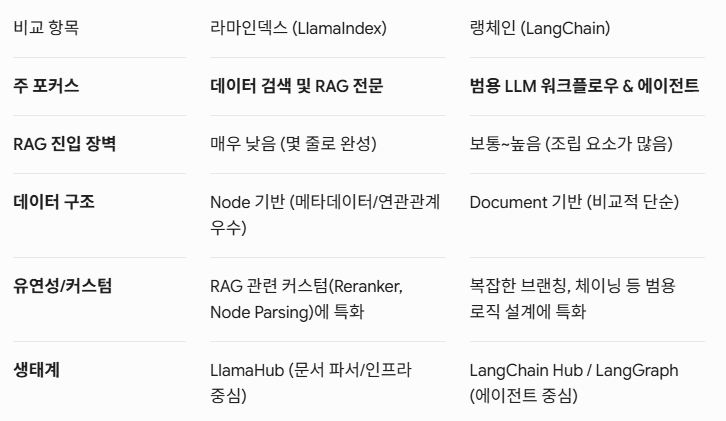

- RAG 전용으로 설계된 아키텍처 LlamaIndex
- 태생 자체가 "데이터를 LLM과 연결하는 RAG/지식 베이스 엔진"입니다. 문서 로딩(SimpleDirectoryReader), 청킹, 인덱싱(VectorStoreIndex), 쿼리 생성(RetrieverQueryEngine)으로 이어지는 RAG의 파이프라인이 하나의 흐름으로 매우 완성도 높게 구성되어 있습니다.

### Docker로 pgvector 기동하기
아래 명령은 **터미널(파이썬 코드 아님)**에서 실행합니다. 

```bash
docker run -d \
  --name edu-pgvector \
  -e POSTGRES_DB=edudb \
  -e POSTGRES_USER=edu \
  -e POSTGRES_PASSWORD=1234 \
  -p 5432:5432 \
  pgvector/pgvector:pg16
```

- `POSTGRES_DB=edudb`, `POSTGRES_USER=edu`, `POSTGRES_PASSWORD=1234` → 이 강의 전체에서 사용할 접속 정보입니다.
- 이미지 `pgvector/pgvector:pg16`은 PostgreSQL 16 + pgvector 확장이 미리 설치되어 있습니다.
- 컨테이너 상태 확인: `docker ps`
- pgvector 확장은 최초 연결 시 LlamaIndex가 `CREATE EXTENSION IF NOT EXISTS vector;`를 자동으로 실행해주므로 별도 설정이 필요 없습니다.

아래 셀에서 파이썬으로 접속 테스트를 해봅니다.

In [ ]:
import psycopg2

PG_CONFIG = {
    "dbname": "edudb",
    "user": "edu",
    "password": "1234",
    "host": "localhost",
    "port": "5432",
}

try:
    conn = psycopg2.connect(**PG_CONFIG)
    print("pgvector(Postgres) 접속 성공 ✅")
    conn.close()
except Exception as e:
    print("접속 실패 ❌ - Docker 컨테이너가 켜져 있는지 확인하세요.")
    print(e)

### LlamaIndex 핵심 개념: Document와 Node

#### Document
`Document`는 원본 데이터 한 건(파일 하나, DB row 하나 등)을 감싸는 객체입니다. <br>
텍스트 본문(`text`)과 부가정보(`metadata`)를 함께 가집니다.

#### Node
`Node`는 Document를 검색하기 좋은 크기로 **잘게 쪼갠 조각(청크)** 입니다. <br>
실제로 벡터 임베딩이 되고 검색되는 단위는 Document가 아니라 **Node** 입니다.

```
Document (문서 1건)
   └── Node 1 (청크)
   └── Node 2 (청크)
   └── Node 3 (청크)
```

먼저 실습용 샘플 문서를 만들어 봅니다.

In [ ]:
import os

os.makedirs("data", exist_ok=True)

sample_docs = {
    "llamaindex_intro.txt": (
        "LlamaIndex는 LLM 애플리케이션을 위한 데이터 프레임워크입니다.\n"
        "문서를 불러오고(Load), 적절한 크기로 나누고(Chunk/Node), "
        "임베딩하여 벡터 저장소에 저장한 뒤(Index), 질문에 맞는 조각을 검색하고(Retrieve), "
        "LLM으로 답변을 생성(Generate)하는 전체 RAG 파이프라인을 지원합니다.\n"
        "핵심 구성 요소로는 Document, Node, Index, Retriever, QueryEngine 등이 있습니다."
    ),
    "pgvector_intro.txt": (
        "pgvector는 PostgreSQL 확장(extension)으로, 벡터 데이터 타입과 "
        "유사도 검색(코사인, L2, 내적 등)을 지원합니다.\n"
        "기존 관계형 데이터베이스에 벡터 검색 기능을 추가할 수 있어, "
        "별도의 벡터 전용 DB 없이도 RAG 시스템을 구축할 수 있다는 장점이 있습니다.\n"
        "HNSW, IVFFlat 같은 인덱스 알고리즘을 지원하여 대규모 데이터에서도 빠른 검색이 가능합니다."
    ),
    "rag_intro.txt": (
        "RAG(Retrieval-Augmented Generation)는 LLM이 답변을 생성하기 전에 "
        "외부 지식 저장소에서 관련 정보를 검색하여 프롬프트에 포함시키는 기법입니다.\n"
        "이를 통해 LLM의 환각(Hallucination) 현상을 줄이고, "
        "최신 정보나 사내 문서처럼 학습되지 않은 데이터에 대해서도 정확한 답변이 가능합니다."
    ),
}

for filename, content in sample_docs.items():
    with open(f"data/{filename}", "w", encoding="utf-8") as f:
        f.write(content)

print("샘플 문서 3개 생성 완료 ✅")
print(os.listdir("data"))

In [ ]:
from llama_index.core import SimpleDirectoryReader

# data 폴더의 모든 파일을 Document 객체 리스트로 읽어옵니다.
documents = SimpleDirectoryReader("data").load_data()

print(f"불러온 Document 개수: {len(documents)}\n")
for doc in documents:
    print("=" * 50)
    print("doc_id :", doc.doc_id)
    print("metadata:", doc.metadata)
    print("본문 미리보기:", doc.text[:60], "...")

In [ ]:
from llama_index.core import Document

manual_doc = Document(
    text="이 문서는 코드에서 직접 생성한 Document 예시입니다.",
    metadata={"source": "manual", "category": "example", "author": "unico"},
)

print(manual_doc)

In [ ]:
from llama_index.llms.openai import OpenAI
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.openai import OpenAIEmbedding
from llama_index.core import Settings

# 1) OpenAI LLM 설정
llm_openai = OpenAI(model="gpt-4o-mini", temperature=0.1)

# 2) Ollama(exaone3.5) LLM 설정 - 로컬 서버(기본 포트 11434)에 연결
llm_ollama = Ollama(
    model="exaone3.5",
    request_timeout=120.0,
    # 로컬이 아닌 다른 서버에서 Ollama를 구동중이라면 base_url을 지정합니다.
    # base_url="http://localhost:11434",
)

# 3) 임베딩 모델 - OpenAI text-embedding-3-small (1536차원)
embed_model = OpenAIEmbedding(model="text-embedding-3-small")

# 4) 전역 Settings에 등록 (이후 별도 지정 없으면 이 값들이 기본으로 사용됨)
Settings.llm = llm_openai          # 기본 LLM은 gpt-4o-mini로 설정
Settings.embed_model = embed_model
Settings.chunk_size = 512
Settings.chunk_overlap = 50

print("Settings 구성 완료 ✅")
print("기본 LLM:", Settings.llm.metadata.model_name)

In [ ]:
from llama_index.core import VectorStoreIndex

# documents(3개 문서)를 임베딩하여 인메모리 벡터 인덱스 생성
index = VectorStoreIndex.from_documents(documents)

print("인덱스 생성 완료 ✅")
print("색인된 Node 개수:", len(index.docstore.docs))


In [ ]:
# 질의응답 엔진(QueryEngine) 생성 - 검색 + LLM 답변 생성을 한 번에 처리
query_engine = index.as_query_engine(similarity_top_k=2)

response = query_engine.query("pgvector는 어떤 장점이 있어?")

print("📝 답변:")
print(response)

print("\n📚 참고한 출처(source_nodes):")
for node_with_score in response.source_nodes:
    print(f"- score={node_with_score.score:.4f} | {node_with_score.node.metadata.get('file_name')}")
    print(f"  내용 미리보기: {node_with_score.node.text[:50]}...")


In [ ]:
response = query_engine.query("김정현 강사는 어디에서 살고 있어?")

print("📝 답변:")
print(response)

print("\n📚 참고한 출처(source_nodes):")
for node_with_score in response.source_nodes:
    print(f"- score={node_with_score.score:.4f} | {node_with_score.node.metadata.get('file_name')}")
    print(f"  내용 미리보기: {node_with_score.node.text[:50]}...")

### 💡 `response` 객체 구조
`query_engine.query(...)`의 반환값은 `Response` 객체이며 주요 속성은 다음과 같습니다.

| 속성 | 설명 |
|---|---|
| `response.response` | LLM이 생성한 최종 답변 텍스트 |
| `response.source_nodes` | 답변 생성에 사용된 Node 목록 (근거 자료) |
| `response.metadata` | 각 소스 노드의 부가 정보 |

`print(response)`는 내부적으로 `response.response`를 출력하는 것과 같습니다.


### 텍스트 청킹(Chunking) 전략 - Node Parser

문서를 얼마나 잘게, 어떤 기준으로 자르느냐가 RAG 품질에 큰 영향을 줍니다.
LlamaIndex는 다양한 `NodeParser`(=Splitter)를 제공합니다.

| Splitter | 특징 |
|---|---|
| `SentenceSplitter` | 문장 경계를 존중하며 chunk_size 단위로 분할 (가장 널리 사용) |
| `TokenTextSplitter` | 순수 토큰 개수 기준으로 분할 |
| `SemanticSplitterNodeParser` | 임베딩 유사도를 이용해 "의미 단위"로 분할 (고급) |
| `SentenceWindowNodeParser` | 문장 단위로 쪼개되, 주변 문맥(window)을 metadata로 함께 저장 |


In [ ]:
from llama_index.core.node_parser import (
    SentenceSplitter,
    TokenTextSplitter,
    SentenceWindowNodeParser,
)

sample_text = documents[0].text  # llamaindex_intro.txt 내용

# 1) SentenceSplitter - 가장 많이 쓰는 기본 splitter
sentence_splitter = SentenceSplitter(chunk_size=100, chunk_overlap=10)
nodes_sentence = sentence_splitter.get_nodes_from_documents(documents)
print(f"[SentenceSplitter] 생성된 Node 개수: {len(nodes_sentence)}")

# 2) TokenTextSplitter - 토큰 개수 기준
token_splitter = TokenTextSplitter(chunk_size=100, chunk_overlap=10)
nodes_token = token_splitter.get_nodes_from_documents(documents)
print(f"[TokenTextSplitter] 생성된 Node 개수: {len(nodes_token)}")

# 3) SentenceWindowNodeParser - 문맥 윈도우 방식 (문장 1개 = Node 1개 + 앞뒤 문맥 저장)
window_parser = SentenceWindowNodeParser.from_defaults(
    window_size=3,
    window_metadata_key="window",
    original_text_metadata_key="original_text",
)
nodes_window = window_parser.get_nodes_from_documents(documents)
print(f"[SentenceWindowNodeParser] 생성된 Node 개수: {len(nodes_window)}")

print("\n--- SentenceWindowNodeParser 예시 Node ---")
print("원본 문장:", nodes_window[0].metadata["original_text"])
print("윈도우(주변 문맥):", nodes_window[0].metadata["window"][:100], "...")


### 💡 SemanticSplitterNodeParser (고급)
고정 길이가 아니라 **문장 간 임베딩 유사도가 급격히 변하는 지점**을 기준으로 나누는 방식입니다.
비용(임베딩 호출)이 더 들지만, 의미적으로 더 자연스러운 청크를 만들 수 있습니다.


In [ ]:
from llama_index.core.node_parser import SemanticSplitterNodeParser

semantic_splitter = SemanticSplitterNodeParser(
    buffer_size=1,              # 비교할 문장 묶음 크기
    breakpoint_percentile_threshold=95,  # 분할 임계값 (높을수록 덜 나뉨)
    embed_model=embed_model,
)

nodes_semantic = semantic_splitter.get_nodes_from_documents(documents)
print(f"[SemanticSplitterNodeParser] 생성된 Node 개수: {len(nodes_semantic)}")


### 응답 합성(Response Synthesis) 전략

검색된 여러 Node를 LLM에게 어떻게 전달해서 하나의 답변으로 합칠지 결정하는 것이
**Response Synthesizer**입니다. `response_mode` 옵션으로 전략을 바꿀 수 있습니다.

| 모드 | 설명 | 언제 사용? |
|---|---|---|
| `compact` (기본값) | 가능한 많은 텍스트를 한 프롬프트에 압축해서 담아 LLM 호출 최소화 | 대부분의 경우 (기본 추천) |
| `refine` | Node 1개씩 순차적으로 답변을 "다듬어가며" 생성 (LLM 여러 번 호출) | 정확도가 매우 중요할 때 |
| `tree_summarize` | Node들을 트리 구조로 요약해 나감 (map-reduce와 유사) | 문서가 매우 많을 때 |
| `simple_summarize` | 모든 텍스트를 하나로 합쳐 한 번만 LLM 호출 (컨텍스트 길이 주의) | 빠른 프로토타이핑 |


In [ ]:
for mode in ["compact", "refine", "tree_summarize"]:
    qe = index.as_query_engine(similarity_top_k=3, response_mode=mode)
    resp = qe.query("LlamaIndex와 RAG, pgvector의 관계를 설명해줘.")
    print(f"=== response_mode = {mode} ===")
    print(resp)
    print()


### Retriever 커스터마이징 & 메타데이터 필터링

`QueryEngine`은 내부적으로 **Retriever**(검색)와 **Response Synthesizer**(답변 생성)로 나뉩니다.
이 둘을 분리해서 다루면 검색 로직을 더 세밀하게 제어할 수 있습니다.


In [ ]:
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine

# 1) Retriever만 따로 사용 - LLM 호출 없이 유사 Node만 검색
retriever = VectorIndexRetriever(index=index, similarity_top_k=2)
nodes = retriever.retrieve("pgvector 인덱스 알고리즘")

print("검색된 Node:")
for n in nodes:
    print(f"- score={n.score:.4f} | {n.node.text[:40]}...")

# 2) Retriever + Synthesizer를 조합해서 QueryEngine 직접 구성
custom_query_engine = RetrieverQueryEngine.from_args(
    retriever=retriever,
    response_mode="compact",
)
print("\n답변:", custom_query_engine.query("pgvector 인덱스 알고리즘 알려줘"))


#### 메타데이터 필터링
문서에 태그를 달아두면, 검색 시 특정 조건에 맞는 문서만 대상으로 검색할 수 있습니다.
예를 들어 "category가 'db'인 문서에서만 검색"처럼 활용합니다.


In [ ]:
from llama_index.core import Document, VectorStoreIndex
from llama_index.core.vector_stores import MetadataFilters, MetadataFilter, FilterOperator

# metadata를 포함한 문서 다시 생성
docs_with_meta = [
    Document(text=documents[0].text, metadata={"category": "framework"}),
    Document(text=documents[1].text, metadata={"category": "db"}),
    Document(text=documents[2].text, metadata={"category": "concept"}),
]
meta_index = VectorStoreIndex.from_documents(docs_with_meta)

filters = MetadataFilters(
    filters=[MetadataFilter(key="category", value="db", operator=FilterOperator.EQ)]
)

filtered_engine = meta_index.as_query_engine(filters=filters, similarity_top_k=2)
response = filtered_engine.query("이 시스템의 장점은?")
print(response)
print("\n검색 대상이 'db' 카테고리로 한정되었는지 확인:")
for n in response.source_nodes:
    print("-", n.node.metadata)


### 후처리(Postprocessing) & 재정렬(Rerank)

1차로 검색된 Node들을 LLM에게 넘기기 전에 **한 번 더 걸러내거나 순서를 조정**할 수 있습니다.

- `SimilarityPostprocessor`: 유사도 점수가 임계값 이하인 Node를 제거
- `KeywordNodePostprocessor`: 특정 키워드 포함/제외 필터링
- Rerank 계열(`ColbertRerank`, `SentenceTransformerRerank` 등): 더 정교한 재정렬 모델로 순위를 다시 매김 (검색 품질 향상의 핵심 기법)


In [ ]:
from llama_index.core.postprocessor import SimilarityPostprocessor

# 유사도 0.75 미만인 결과는 제외
postprocessor = SimilarityPostprocessor(similarity_cutoff=0.75)

pp_engine = index.as_query_engine(
    similarity_top_k=5,
    node_postprocessors=[postprocessor],
)

response = pp_engine.query("RAG의 장점은 무엇인가요?")
print(response)
print(f"\n필터링 후 사용된 소스 개수: {len(response.source_nodes)}")


### 💡 Rerank 모델 사용 예시 (참고용 코드)
Rerank는 별도 모델(Cross-Encoder 등)을 다운로드해야 하므로 이번 강의에서는 실행하지 않지만,
실무에서 검색 품질을 크게 올려주는 중요한 기법이므로 코드 형태만 소개합니다.

```python
from llama_index.postprocessor.colbert_rerank import ColbertRerank

reranker = ColbertRerank(top_n=3)
rerank_engine = index.as_query_engine(
    similarity_top_k=10,       # 넉넉하게 후보를 뽑고
    node_postprocessors=[reranker],  # 그중 상위 3개로 재정렬
)
```


### Chat Engine - 대화형 RAG

`QueryEngine`은 질문 하나에 답변 하나(무상태, stateless)입니다.
반면 `ChatEngine`은 **이전 대화 맥락을 기억**하면서 RAG를 수행합니다.

| chat_mode | 설명 |
|---|---|
| `condense_question` | 이전 대화 + 현재 질문을 "독립된 질문 하나"로 재작성한 뒤 검색 |
| `context` | 매 턴마다 검색을 수행하고, 그 결과를 항상 시스템 프롬프트에 주입 |
| `condense_plus_context` | 위 두 방식을 결합 (가장 널리 사용되는 실전형 모드) |
| `react` | ReAct 에이전트처럼 스스로 검색 필요 여부를 판단 |


In [ ]:
chat_engine = index.as_chat_engine(
    chat_mode="condense_plus_context",
    llm=llm_openai,
    system_prompt=(
        "당신은 LlamaIndex와 RAG 시스템 전문가입니다. "
        "주어진 컨텍스트를 바탕으로 친절하고 정확하게 한국어로 답변하세요."
    ),
)

r1 = chat_engine.chat("pgvector가 뭐야?")
print("👤 pgvector가 뭐야?")
print("🤖", r1, "\n")

r2 = chat_engine.chat("방금 말한 그 기술은 어떤 인덱스 알고리즘을 지원해?")
print("👤 방금 말한 그 기술은 어떤 인덱스 알고리즘을 지원해?")
print("🤖", r2)


In [ ]:
# 대화 히스토리 초기화
chat_engine.reset()
print("대화 히스토리 초기화 완료 ✅")


### 구조화된 출력 (Structured Output)

RAG 답변을 자유 텍스트가 아니라 **정해진 JSON 스키마(Pydantic 모델)** 로 받고 싶을 때 사용합니다.
프론트엔드 렌더링, DB 저장, 다른 시스템과의 연동 시 매우 유용합니다.


In [ ]:
from pydantic import BaseModel, Field
from typing import List

class TechSummary(BaseModel):
    "기술 개념 요약 스키마"
    topic: str = Field(description="주제명")
    one_line_summary: str = Field(description="한 문장 요약")
    key_points: List[str] = Field(description="핵심 포인트 3가지")

structured_query_engine = index.as_query_engine(
    output_cls=TechSummary,
    response_mode="compact",
)

response = structured_query_engine.query("pgvector에 대해 정리해줘")
print(type(response.response))
print(response.response)


### Agent & Tool 사용

**Agent** 는 LLM이 스스로 "어떤 도구(Tool)를 사용할지, 언제 멈출지"를 판단하며
여러 단계를 거쳐 문제를 해결하는 방식입니다.<br> RAG 쿼리 엔진도 하나의 Tool로 등록해서
"검색이 필요하면 검색하고, 아니면 그냥 답변하는" 유연한 시스템을 만들 수 있습니다.

최신 LlamaIndex는 `FunctionAgent`(함수 호출 기반, 권장) 방식을 제공합니다.


In [ ]:
from llama_index.core.agent.workflow import FunctionAgent
from llama_index.core.tools import FunctionTool, QueryEngineTool
import asyncio

# 1) 일반 파이썬 함수를 Tool로 등록
def get_current_year() -> int:
    "현재 연도를 반환합니다."
    return 2026

year_tool = FunctionTool.from_defaults(fn=get_current_year)

# 2) RAG 쿼리 엔진도 Tool로 등록
rag_tool = QueryEngineTool.from_defaults(
    query_engine=index.as_query_engine(),
    name="rag_search",
    description="LlamaIndex, pgvector, RAG 관련 사내 문서를 검색합니다.",
)

agent = FunctionAgent(
    tools=[year_tool, rag_tool],
    llm=llm_openai,
    system_prompt="필요할 때만 도구를 사용하고, 한국어로 답변하는 어시스턴트입니다.",
)

async def run_agent(question: str):
    response = await agent.run(question)
    return response

# Jupyter는 이미 이벤트 루프가 돌고 있으므로 await를 바로 사용합니다.
result = await run_agent("올해가 몇 년도인지 알려주고, pgvector가 뭔지도 검색해서 알려줘.")
print(result)


### Docker로 pgvector 기동하기
아래 명령은 **터미널(파이썬 코드 아님)**에서 실행합니다. 

```bash
docker run -d \
  --name edu-pgvector \
  -e POSTGRES_DB=edudb \
  -e POSTGRES_USER=edu \
  -e POSTGRES_PASSWORD=1234 \
  -p 5432:5432 \
  pgvector/pgvector:pg16
```

- `POSTGRES_DB=edudb`, `POSTGRES_USER=edu`, `POSTGRES_PASSWORD=1234` → 이 강의 전체에서 사용할 접속 정보입니다.
- 이미지 `pgvector/pgvector:pg16`은 PostgreSQL 16 + pgvector 확장이 미리 설치되어 있습니다.
- 컨테이너 상태 확인: `docker ps`
- pgvector 확장은 최초 연결 시 LlamaIndex가 `CREATE EXTENSION IF NOT EXISTS vector;`를 자동으로 실행해주므로 별도 설정이 필요 없습니다.

아래 셀에서 파이썬으로 접속 테스트를 해봅니다.

In [ ]:
import psycopg2

PG_CONFIG = {
    "dbname": "edudb",
    "user": "edu",
    "password": "1234",
    "host": "localhost",
    "port": "5432",
}

try:
    conn = psycopg2.connect(**PG_CONFIG)
    print("pgvector(Postgres) 접속 성공 ✅")
    conn.close()
except Exception as e:
    print("접속 실패 ❌ - Docker 컨테이너가 켜져 있는지 확인하세요.")
    print(e)

### 🔑 pgvector 벡터 DB 연동 (핵심 파트)

지금까지는 벡터를 **메모리**에 저장했습니다. 이제 실무처럼 **Docker의 PostgreSQL(pgvector)**에
영구 저장하고, 언제든 다시 불러와서 사용하는 방법을 배웁니다.

#### PGVectorStore 생성
`PGVectorStore.from_params(...)`로 접속 정보를 지정하면, 테이블이 없을 경우 자동으로 생성해줍니다.

> 접속 정보 (강의 공통): `dbname=edudb`, `user=edu`, `password=1234`, `host=localhost`, `port=5432`


In [ ]:
from llama_index.vector_stores.postgres import PGVectorStore

# text-embedding-3-small은 1536차원 벡터를 생성합니다.
EMBED_DIM = 1536

pg_vector_store = PGVectorStore.from_params(
    database="edudb",
    host="localhost",
    port="5432",
    user="edu",
    password="1234",
    table_name="llamaindex_lecture",   # 실제 테이블명은 data_llamaindex_lecture 로 생성됨
    embed_dim=EMBED_DIM,
    hnsw_kwargs={                       # HNSW 근사 최근접 이웃 인덱스 파라미터
        "hnsw_m": 16,
        "hnsw_ef_construction": 64,
        "hnsw_ef_search": 40,
        "hnsw_dist_method": "vector_cosine_ops",
    },
)

print("PGVectorStore 생성 완료 ✅ (테이블: data_llamaindex_lecture)")


#### StorageContext + VectorStoreIndex로 문서 색인 → pgvector에 저장


In [ ]:
from llama_index.core import StorageContext, VectorStoreIndex

storage_context = StorageContext.from_defaults(vector_store=pg_vector_store)

pg_index = VectorStoreIndex.from_documents(
    documents,                     # 앞서 만든 3개 샘플 문서
    storage_context=storage_context,
    show_progress=True,
)

print("pgvector에 임베딩 저장 완료 ✅")

In [ ]:
# SQL로 실제 저장된 데이터 확인
import psycopg2

conn = psycopg2.connect(**PG_CONFIG)
cur = conn.cursor()
cur.execute("SELECT count(*) FROM data_llamaindex_lecture;")
print("저장된 row 수:", cur.fetchone()[0])

cur.execute("SELECT id, node_id, text FROM data_llamaindex_lecture LIMIT 2;")
for row in cur.fetchall():
    print(row[0], row[1], str(row[2])[:40], "...")

cur.close()
conn.close()


#### 저장된 pgvector 인덱스 다시 불러오기 (재임베딩 없이!)
서버를 재시작하거나 다른 스크립트에서, **이미 저장된 벡터를 재사용** 하려면
`from_vector_store()`를 사용합니다.<br> 이 방법은 문서를 다시 읽거나 임베딩을 다시 만들지 않으므로
비용과 시간을 절약할 수 있습니다.


In [ ]:
from llama_index.core import VectorStoreIndex

# 새로운 PGVectorStore 객체(같은 테이블을 가리킴)를 만들고 연결만 함
reconnect_store = PGVectorStore.from_params(
    database="edudb", host="localhost", port="5432",
    user="edu", password="1234",
    table_name="llamaindex_lecture", embed_dim=EMBED_DIM,
)

restored_index = VectorStoreIndex.from_vector_store(reconnect_store)

query_engine = restored_index.as_query_engine(similarity_top_k=2)
response = query_engine.query("RAG는 왜 필요한가요?")
print(response)


In [ ]:
response = query_engine.query("김정현강사의 별명은 무엇인가요?")
print(response)

#### 하이브리드 검색 (Hybrid Search)
**벡터 유사도 검색(의미 기반)** + **키워드 검색(정확한 단어 매칭, BM25 계열)** 을 함께 사용하면
"고유명사, 코드, 숫자"처럼 벡터 검색이 약한 영역에서도 검색 품질을 높일 수 있습니다.

`hybrid_search=True` 옵션 하나로 pgvector의 전문검색(full-text search) 기능과 결합됩니다.


In [ ]:
hybrid_store = PGVectorStore.from_params(
    database="edudb", host="localhost", port="5432",
    user="edu", password="1234",
    table_name="llamaindex_hybrid",
    embed_dim=EMBED_DIM,
    hybrid_search=True,
    text_search_config="english",   # 한국어 형태소 분석 확장을 쓰면 "korean" 등으로 교체 가능
)

hybrid_storage_context = StorageContext.from_defaults(vector_store=hybrid_store)
hybrid_index = VectorStoreIndex.from_documents(
    documents, storage_context=hybrid_storage_context, show_progress=True
)

hybrid_query_engine = hybrid_index.as_query_engine(
    vector_store_query_mode="hybrid",
    similarity_top_k=3,
    sparse_top_k=3,           # 키워드 검색 후보 개수
)

response = hybrid_query_engine.query("pgvector HNSW 인덱스")
print(response)


### IngestionPipeline - 증분 색인 & 파이프라인 관리

실무에서는 문서가 한 번에 다 들어오는 게 아니라 **계속 추가/수정**됩니다.
매번 전체를 다시 임베딩하면 비용 낭비이므로, `IngestionPipeline`은
**변경된 문서만 감지해서 처리**하는 캐싱/증분 색인 기능을 제공합니다.


In [ ]:
from llama_index.core.ingestion import IngestionPipeline, IngestionCache
from llama_index.core.node_parser import SentenceSplitter

pipeline_store = PGVectorStore.from_params(
    database="edudb", host="localhost", port="5432",
    user="edu", password="1234",
    table_name="llamaindex_pipeline",
    embed_dim=EMBED_DIM,
)

pipeline = IngestionPipeline(
    transformations=[
        SentenceSplitter(chunk_size=256, chunk_overlap=20),
        embed_model,
    ],
    vector_store=pipeline_store,
    cache=IngestionCache(),   # 동일 문서 재입력 시 중복 임베딩 방지
)

nodes = pipeline.run(documents=documents, show_progress=True)
print(f"파이프라인 처리 완료 - Node {len(nodes)}개 생성/저장 ✅")

# 같은 문서를 다시 실행하면? -> 캐시 덕분에 중복 임베딩 없이 스킵됩니다.
nodes_again = pipeline.run(documents=documents, show_progress=True)
print(f"재실행 결과 - Node {len(nodes_again)}개 (캐시로 인해 임베딩 재호출 없음)")


### 🎓 최종 프로젝트: pgvector 기반 RAG 챗봇

지금까지 배운 내용을 종합해서 실제로 동작하는 RAG 챗봇을 구현합니다.

**요구사항**
1. `data/` 폴더의 문서를 읽어 pgvector에 저장 (이미 완료된 인덱스 재사용)
2. `gpt-4o-mini`와 `exaone3.5(Ollama)` 중 원하는 모델을 선택해서 답변받을 수 있어야 함
3. 대화 맥락을 기억하는 Chat Engine 사용
4. 답변과 함께 **참고한 출처(파일명)**를 함께 보여줄 것


In [ ]:
from llama_index.core.memory import ChatMemoryBuffer


class PgVectorRAGChatbot:
    "pgvector 기반 RAG 챗봇 - OpenAI / Ollama 모델 선택 가능"

    def __init__(self, vector_store, embed_model, llm):
        self.index = VectorStoreIndex.from_vector_store(
            vector_store, embed_model=embed_model
        )
        self.llm = llm
        self.memory = ChatMemoryBuffer.from_defaults(token_limit=3000)
        self.chat_engine = self.index.as_chat_engine(
            chat_mode="condense_plus_context",
            llm=self.llm,
            memory=self.memory,
            system_prompt=(
                "당신은 사내 기술 문서를 기반으로 답변하는 어시스턴트입니다. "
                "모르는 내용은 모른다고 솔직히 말하고, 반드시 한국어로 답하세요."
            ),
        )

    def ask(self, question: str):
        response = self.chat_engine.chat(question)
        sources = sorted({
            n.node.metadata.get("file_name", "unknown")
            for n in response.source_nodes
        })
        return response.response, sources

    def reset(self):
        self.chat_engine.reset()


# 최종적으로 저장해둔 llamaindex_lecture 테이블을 재사용
final_store = PGVectorStore.from_params(
    database="edudb", host="localhost", port="5432",
    user="edu", password="1234",
    table_name="llamaindex_lecture", embed_dim=EMBED_DIM,
)

# gpt-4o-mini 버전 챗봇
chatbot_openai = PgVectorRAGChatbot(final_store, embed_model, llm_openai)

# exaone3.5(Ollama) 버전 챗봇
chatbot_ollama = PgVectorRAGChatbot(final_store, embed_model, llm_ollama)

for name, bot in [("gpt-4o-mini", chatbot_openai), ("exaone3.5", chatbot_ollama)]:
    print(f"\n================ {name} ================")
    answer, sources = bot.ask("pgvector와 RAG를 함께 쓰면 어떤 점이 좋은지 알려줘.")
    print("답변:", answer)
    print("출처:", sources)


In [ ]:
# 대화 맥락 유지 확인 (gpt-4o-mini 챗봇으로 이어서 대화)
answer2, sources2 = chatbot_openai.ask("방금 말한 내용을 초등학생도 이해하게 다시 설명해줘.")
print("답변:", answer2)
print("출처:", sources2)


### 💬 간단한 대화형 루프 (터미널/로컬 환경에서 실행)
Jupyter가 아닌 일반 Python 스크립트(`chatbot.py`)로 실행할 때 사용할 수 있는
CLI 대화 루프 예시입니다. (Jupyter 안에서는 `input()`이 블로킹되므로 참고용으로만 제공)

```python
if __name__ == "__main__":
    bot = PgVectorRAGChatbot(final_store, embed_model, llm_openai)
    print("RAG 챗봇을 시작합니다. 종료하려면 'exit' 입력.")
    while True:
        q = input("\n질문> ")
        if q.strip().lower() == "exit":
            break
        answer, sources = bot.ask(q)
        print("답변:", answer)
        print("출처:", sources)
```


### 마무리 & 추가 학습 자료

#### 학습 내용 정리
- LlamaIndex 핵심 개념: `Document` → `Node` → `Index` → `Retriever` → `QueryEngine`
- `Settings`를 통한 LLM(`gpt-4o-mini`, `exaone3.5`) / Embedding 전역 설정
- 다양한 Node Parser(청킹 전략), Response Synthesis 모드
- Retriever 커스터마이징, 메타데이터 필터링, 후처리/Rerank
- `ChatEngine`을 이용한 대화형 RAG
- `SubQuestionQueryEngine`, `HyDE` 등 고급 쿼리 기법
- Pydantic 기반 구조화된 출력
- `FunctionAgent`를 이용한 도구(Tool) 기반 에이전트
- **pgvector 연동**: 저장, 재연결, 하이브리드 검색, HNSW 인덱스 튜닝
- `IngestionPipeline`을 이용한 증분 색인
- 최종 프로젝트: OpenAI/Ollama 모델 선택 가능한 pgvector RAG 챗봇

#### 참고 자료
- LlamaIndex 공식 문서: https://docs.llamaindex.ai
- pgvector GitHub: https://github.com/pgvector/pgvector
- Ollama 모델 허브: https://ollama.com/library

#### 다음 단계로 도전해볼 것들
1. `SimpleDirectoryReader`로 PDF/PPTX 등 실제 사내 문서를 읽어 색인해보기
2. `SentenceTransformerRerank`로 검색 품질 개선 실험
3. FastAPI로 이 챗봇을 REST API로 감싸서 서비스화
4. LangGraph와 결합해 멀티 에이전트 RAG 시스템으로 확장


### 라마인덱스(LlamaIndex)!! 꽤 괜찮은 RAG 기반 프레임워크네요^^

#### 라마인덱스(LlamaIndex)는 대형 언어 모델(LLM)과 사내 문서, PDF, 데이터베이스 같은 외부 데이터를 쉽게 연결해 주는 오픈소스 데이터 프레임워크입니다. 주로 RAG(검색 증강 생성) 시스템이나 AI 챗봇을 빠르고 간단하게 만들 때 사용합니다.